## 0. Import & Initialization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch
import torch.nn as nn
import torch.optim as optim

# Set seeds
np.random.seed(0)
torch.manual_seed(0)

## 1. Define the Himmelblau Function

In [2]:
T_TEMP = 20.0            # Temperature for the distribution

# 1. Define the Himmelblau Function
def himmelblau(x):
    return (x[0]**2 + x[1] - 11)**2 + (x[0] + x[1]**2 - 7)**2

# 2. Define the Log-Probability (Target Distribution)
# We use log-probability for numerical stability in MCMC later
def log_prob_himmelblau(x, T=1.0):
    # x is a numpy array of shape (..., 2)
    f_val = (x[..., 0]**2 + x[..., 1] - 11)**2 + (x[..., 0] + x[..., 1]**2 - 7)**2
    return -f_val / T

def log_prob_himmelblau_torch(x, T=1.0):
    """
    PyTorch-compatible log probability for Himmelblau function.
    x: torch tensor of shape (..., 2)
    """
    # Ensure x is a tensor
    if not torch.is_tensor(x):
        x = torch.tensor(x, dtype=torch.float32)
        
    term1 = (x[..., 0]**2 + x[..., 1] - 11)**2
    term2 = (x[..., 0] + x[..., 1]**2 - 7)**2
    f_val = term1 + term2
    
    return -f_val / T

## 2. Visualize the Function

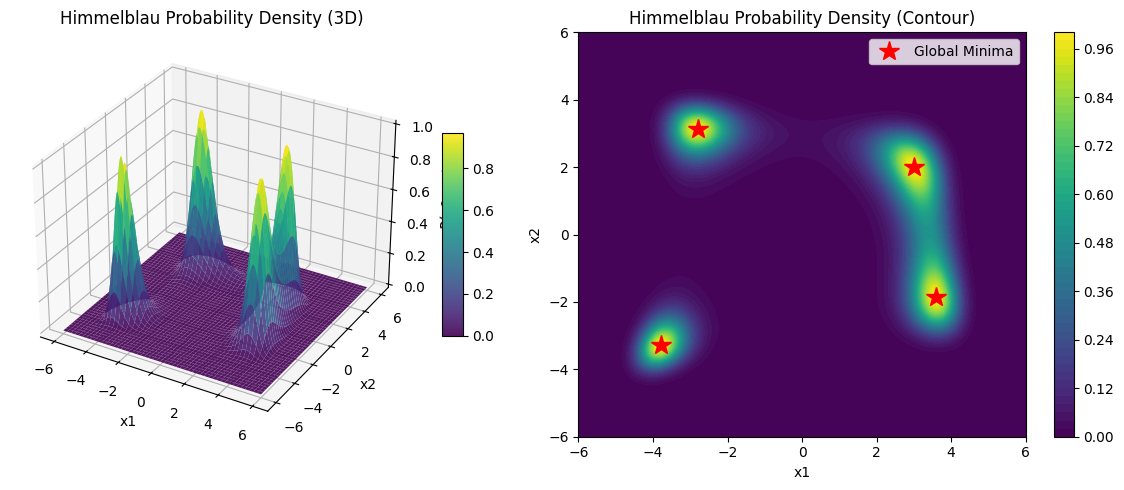

In [3]:
# 3. Create a Grid for Visualization
x_range = np.linspace(-6, 6, 400)
y_range = np.linspace(-6, 6, 400)
X, Y = np.meshgrid(x_range, y_range)
pos = np.dstack((X, Y)) # Shape: (400, 400, 2)

# Calculate Z values (Probability Density)
Z = np.exp(log_prob_himmelblau(pos, T=T_TEMP))

# 4. Plotting
fig = plt.figure(figsize=(12, 5))

# Plot 1: 3D Surface Plot
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)
ax1.set_title('Himmelblau Probability Density (3D)')
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_zlabel('P(x1, x2)')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

# Plot 2: Contour Plot (Top-down view)
ax2 = fig.add_subplot(122)
contour = ax2.contourf(X, Y, Z, levels=50, cmap='viridis')
ax2.set_title('Himmelblau Probability Density (Contour)')
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
fig.colorbar(contour, ax=ax2)

# Mark the 4 known minima for reference
minima = np.array([
    [3.0, 2.0],
    [-2.805118, 3.131312],
    [-3.779310, -3.283186],
    [3.584428, -1.848126]
])
ax2.plot(minima[:, 0], minima[:, 1], 'r*', markersize=15, label='Global Minima')
ax2.legend()

plt.tight_layout()
plt.savefig('../assets/himmelblau_density.png', dpi=300)
plt.show()

## 3. Classical MCMC Sampling (Metropolis-Hastings)

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Configuration ---
N_SAMPLES = 6000       # Total number of steps
BURN_IN = 1000          # Steps to discard at the start
PROPOSAL_STD = 1      # Standard deviation of the random walk proposal

In [5]:
# --- 2. Classical Random Walk Metropolis Function ---
def classical_mh(log_prob_fn, n_samples, initial_state, prop_std):
    """
    Runs Classical Random Walk Metropolis.
    """
    dim = len(initial_state)
    samples = np.zeros((n_samples, dim))
    current_state = np.array(initial_state, dtype=float)
    
    # Calculate initial log probability
    current_log_prob = log_prob_fn(current_state, T=T_TEMP)
    
    accepted_count = 0
    
    for i in range(n_samples):
        # 1. Propose: Add Gaussian noise
        # q(x* | x_t) = N(x_t, prop_std^2 * I)
        proposal = current_state + np.random.normal(0, prop_std, size=dim)
        
        # 2. Calculate Log Probability of Proposal
        proposal_log_prob = log_prob_fn(proposal, T=T_TEMP)
        
        # 3. Acceptance Ratio (Log Space)
        # Since proposal is symmetric, Hastings correction is 0
        log_alpha = proposal_log_prob - current_log_prob
        
        # 4. Accept/Reject
        if np.log(np.random.rand()) < log_alpha:
            current_state = proposal
            current_log_prob = proposal_log_prob
            accepted_count += 1
            
        # 5. Store Sample
        samples[i] = current_state
        
    acceptance_rate = accepted_count / n_samples
    return samples, acceptance_rate

In [6]:
# --- 3. Run Classical MH ---
print("Running Classical MCMC...")
initial_state = [0.0, 0.0] # Start at origin (low probability region)
samples_classical, acc_rate_classical = classical_mh(
    log_prob_himmelblau, 
    N_SAMPLES, 
    initial_state, 
    PROPOSAL_STD
)

print(f"Classical Acceptance Rate: {acc_rate_classical:.2f}")

Running Classical MCMC...
Classical Acceptance Rate: 0.35


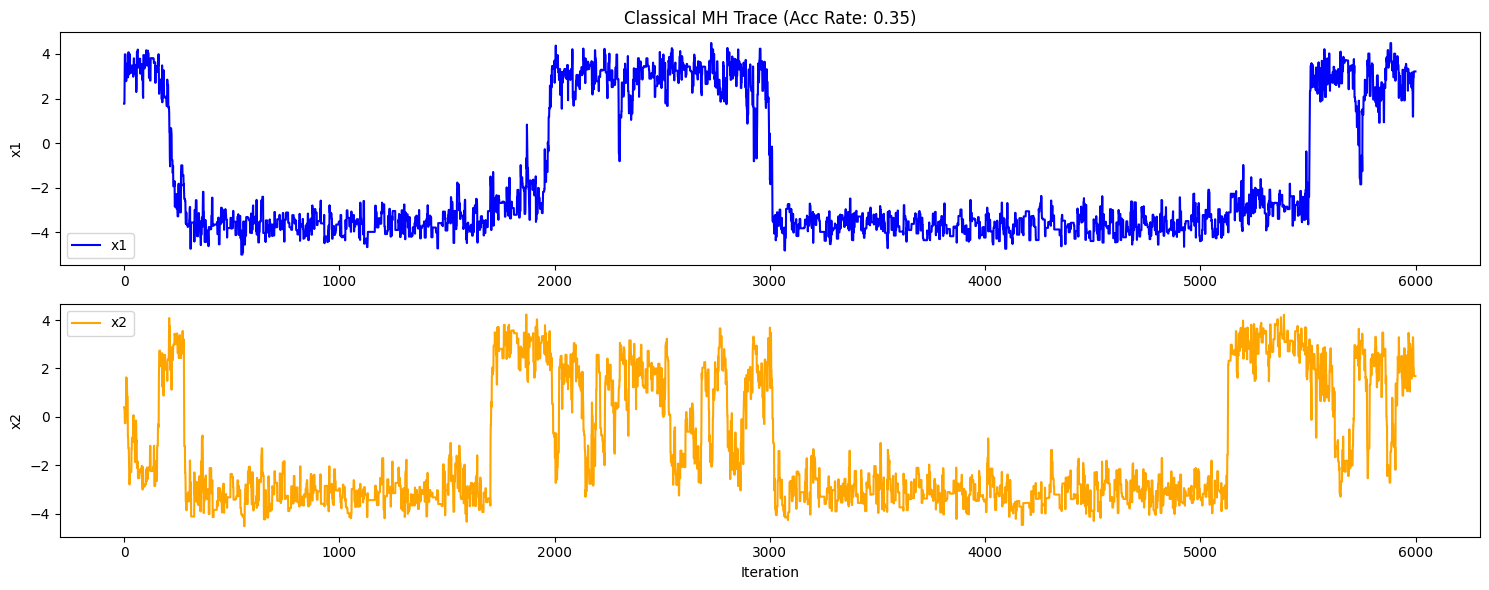

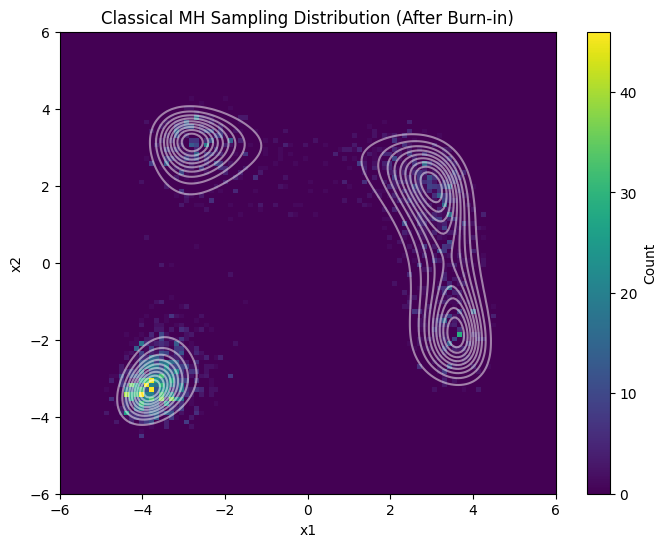

In [7]:
# --- 4. Visualization of Classical Results ---

# A. Trace Plot (How the values change over time)
fig, axes = plt.subplots(2, 1, figsize=(15, 6))
axes[0].plot(samples_classical[:, 0], label='x1', color='blue')
axes[0].set_ylabel('x1')
axes[0].legend()
axes[0].set_title(f'Classical MH Trace (Acc Rate: {acc_rate_classical:.2f})')

axes[1].plot(samples_classical[:, 1], label='x2', color='orange')
axes[1].set_ylabel('x2')
axes[1].set_xlabel('Iteration')
axes[1].legend()

plt.tight_layout()
plt.show()

# B. 2D Histogram (Where did the sampler go?)
plt.figure(figsize=(8, 6))
plt.hist2d(samples_classical[BURN_IN:, 0], samples_classical[BURN_IN:, 1], 
           bins=100, cmap='viridis', range=[[-6, 6], [-6, 6]])
plt.colorbar(label='Count')
plt.title('Classical MH Sampling Distribution (After Burn-in)')
plt.xlabel('x1')
plt.ylabel('x2')

# Overlay the true contours for reference
x_range = np.linspace(-6, 6, 200)
y_range = np.linspace(-6, 6, 200)
X, Y = np.meshgrid(x_range, y_range)
Z = np.exp(log_prob_himmelblau(np.dstack((X, Y)), T=T_TEMP))
plt.contour(X, Y, Z, levels=10, colors='white', alpha=0.5)

plt.show()

## 3. MH Sampling with Learned Proposals (NeuralMH)

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [9]:
class AdaptiveStepNet(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64):
        super(AdaptiveStepNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim) # Output log_std for each dimension
        )
        
        # Initialize weights
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        """
        x: tensor of shape (batch, input_dim)
        returns: log_std (batch, input_dim)
        Note: Mean is implicitly 0 (centered at current state)
        """
        log_std = self.net(x)
        # Clamp to prevent extreme variances
        # std range: [exp(-3), exp(2)] approx [0.05, 7.4]
        log_std = torch.clamp(log_std, min=-3)
        return log_std

In [10]:
def compute_gaussian_entropy(log_std):
    """
    Compute entropy of a diagonal Gaussian.
    H = 0.5 * sum(log(2*pi*e*std^2))
    """
    # log_std is (batch, dim)
    dim = log_std.shape[1]
    # Entropy per dimension: 0.5 * (log(2*pi) + 1 + 2*log_std)
    entropy_per_dim = 0.5 * (np.log(2 * np.pi) + 1 + 2 * log_std)
    # Sum over dimensions
    total_entropy = entropy_per_dim.sum(dim=1)
    return total_entropy

def variational_loss(log_prob_target, log_std, beta=1.0):
    """
    Compute the Variational Loss:
    L = -log P(x*) - beta * H(Q)
    
    log_prob_target: log P(x*) for the proposed samples
    log_std: log standard deviation output by the network
    beta: entropy regularization weight
    """
    entropy = compute_gaussian_entropy(log_std)
    loss = -log_prob_target - beta * entropy
    # print(f"Mean Log Prob: {log_prob_target.mean().item():.4f}, Mean Entropy: {entropy.mean().item():.4f}, Loss: {loss.mean().item():.4f}")
    return loss.mean()

In [11]:
def neural_mh_step_variational(current_state, log_prob_fn, model, optimizer, 
                               beta=1.0, min_std=0.1, T=20.0):
    """
    Strict Metropolis-Hastings with Differentiable Sampling & Correct Hastings Correction.
    """
    dim = len(current_state)
    current_tensor = torch.tensor(current_state, dtype=torch.float32).unsqueeze(0)
    
    # 1. Get log_std from network
    log_std_fwd = model(current_tensor)
    std_fwd = torch.clamp(torch.exp(log_std_fwd), min=min_std)
    
    # 2. Forward Proposal: q(x* | x_t) = N(x_t, std_fwd^2)
    # Center the distribution at current_tensor, NOT zero!
    dist_fwd = torch.distributions.Normal(current_tensor, std_fwd)
    proposal_tensor = dist_fwd.rsample() # Differentiable sampling
    proposal_np = proposal_tensor.detach().numpy()[0]
    
    # Correct log q(x* | x_t)
    log_q_fwd = dist_fwd.log_prob(proposal_tensor).sum(dim=1).item()
    
    # 3. Compute Acceptance Ratio
    current_log_p = log_prob_fn(current_state, T=T)
    proposal_log_p_np = log_prob_fn(proposal_np, T=T)
    log_target_ratio = proposal_log_p_np - current_log_p
    
    # Backward Proposal: q(x_t | x*) = N(x*, std_bwd^2)
    with torch.no_grad():
        proposal_tensor_det = proposal_tensor.detach()
        log_std_bwd = model(proposal_tensor_det)
        std_bwd = torch.clamp(torch.exp(log_std_bwd), min=min_std)
        
        dist_bwd = torch.distributions.Normal(proposal_tensor_det, std_bwd)
        log_q_bwd = dist_bwd.log_prob(current_tensor).sum(dim=1).item()
    
    # Hastings Correction
    log_correction = log_q_bwd - log_q_fwd
    log_alpha = min(log_target_ratio + log_correction, 0.0)
    
    # 4. Accept/Reject (Strict MH)
    accepted = np.log(np.random.rand()) < log_alpha
    next_state = proposal_np if accepted else current_state
    
    # 5. Training Step
    optimizer.zero_grad()
    proposal_log_p_torch = log_prob_fn(proposal_tensor, T=T)
    loss = variational_loss(proposal_log_p_torch, log_std_fwd, beta=beta)
    
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    
    return next_state, accepted, loss.item()

In [12]:
from collections import deque

def run_variational_mcmc(log_prob_fn, n_samples, initial_state, 
                         warmup_steps=2000, prop_std_init=1.0,
                         hidden_dim=64, lr=1e-3, beta=1.0,
                         min_std=0.1, T=20.0):
    """
    Run Variational Adaptive MCMC.
    """
    dim = len(initial_state)
    samples = np.zeros((n_samples, dim))
    
    # Initialize model
    model = AdaptiveStepNet(input_dim=dim, hidden_dim=hidden_dim)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    current_state = np.array(initial_state, dtype=float)
    accepted_count = 0
    loss_history = []
    std_history = [] # To monitor how step-size evolves
    
    print("Starting Variational Adaptive MCMC...")
    # Sliding window for acceptance rate
    window_size = 500
    recent_accepts = deque(maxlen=window_size)
    sliding_acc_rates = []
    
    for i in range(n_samples):
        # Warm-up: Classical Random Walk
        if i < warmup_steps:
            proposal = current_state + np.random.normal(0, prop_std_init, size=dim)
            current_log_p = log_prob_fn(current_state, T=T)
            proposal_log_p = log_prob_fn(proposal, T=T)
            log_alpha = proposal_log_p - current_log_p
            
            if np.log(np.random.rand()) < log_alpha:
                current_state = proposal
                accepted_count += 1
                recent_accepts.append(1)
            else:
                recent_accepts.append(0)
        else:
            # Variational Adaptive Step
            current_state, accepted, loss = neural_mh_step_variational(
                current_state, log_prob_fn, model, optimizer,
                beta=beta, min_std=min_std, T=T
            )
            if accepted:
                accepted_count += 1
                recent_accepts.append(1)
            else:
                recent_accepts.append(0)
            loss_history.append(loss)
            
            # Monitor predicted std (average over dims)
            with torch.no_grad():
                curr_tensor = torch.tensor(current_state, dtype=torch.float32).unsqueeze(0)
                pred_log_std = model(curr_tensor)
                avg_std = np.mean(np.exp(pred_log_std.numpy()[0]))
                std_history.append(avg_std)
        
        samples[i] = current_state
        
        if (i+1) % 1000 == 0:
            current_sliding_acc = np.mean(recent_accepts) if recent_accepts else 0
            acc_rate = accepted_count / (i+1)
            print(f"Step {i+1}/{n_samples}, Acc Rate: {acc_rate:.3f}")
            print(f"  Sliding Acc Rate: {current_sliding_acc:.3f}")
            if loss_history:
                print(f"  Recent Loss: {loss_history[-1]:.4f}")
                print(f"  Avg Loss (last 1000): {np.mean(loss_history[-1000:]):.4f}")
                print(f"  Avg Predicted Std: {np.mean(std_history[-1000:]):.4f}")
    
    overall_acc_rate = accepted_count / n_samples
    print(f"\nComplete. Overall Acceptance Rate: {overall_acc_rate:.3f}")
    
    return samples, overall_acc_rate, model, loss_history, std_history

In [13]:
# --- Execute ---

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("="*50)
print("Running Variational Adaptive MCMC")
print("="*50)

N_SAMPLES_TRAIN = 20000
INITIAL_STATE = [0.0, 0.0]

# Try beta=1.0 first. If variance collapses, increase to 5.0 or 10.0
samples_variational, acc_rate_variational, var_model, loss_hist_var, std_hist_var = run_variational_mcmc(
    log_prob_himmelblau_torch,
    n_samples=N_SAMPLES_TRAIN,
    initial_state=INITIAL_STATE,
    warmup_steps=2000,
    prop_std_init=5.0,
    hidden_dim=64,
    lr=1e-3,
    beta=1.0,       # Start with theoretical value
    min_std=0.1,
    T=T_TEMP
)

Running Variational Adaptive MCMC
Starting Variational Adaptive MCMC...
Step 1000/20000, Acc Rate: 0.088
  Sliding Acc Rate: 0.098
Step 2000/20000, Acc Rate: 0.079
  Sliding Acc Rate: 0.058
Step 3000/20000, Acc Rate: 0.190
  Sliding Acc Rate: 0.422
  Recent Loss: -2.7755
  Avg Loss (last 1000): 1.9633
  Avg Predicted Std: 0.7511
Step 4000/20000, Acc Rate: 0.238
  Sliding Acc Rate: 0.408
  Recent Loss: -1.3734
  Avg Loss (last 1000): 9.6256
  Avg Predicted Std: 1.4319
Step 5000/20000, Acc Rate: 0.268
  Sliding Acc Rate: 0.400
  Recent Loss: -2.2993
  Avg Loss (last 1000): 5.6477
  Avg Predicted Std: 1.3208
Step 6000/20000, Acc Rate: 0.285
  Sliding Acc Rate: 0.340
  Recent Loss: -0.4590
  Avg Loss (last 1000): 4.7609
  Avg Predicted Std: 1.3249
Step 7000/20000, Acc Rate: 0.300
  Sliding Acc Rate: 0.408
  Recent Loss: 0.6836
  Avg Loss (last 1000): 5.3511
  Avg Predicted Std: 1.4706
Step 8000/20000, Acc Rate: 0.309
  Sliding Acc Rate: 0.376
  Recent Loss: 0.9267
  Avg Loss (last 1000): 1

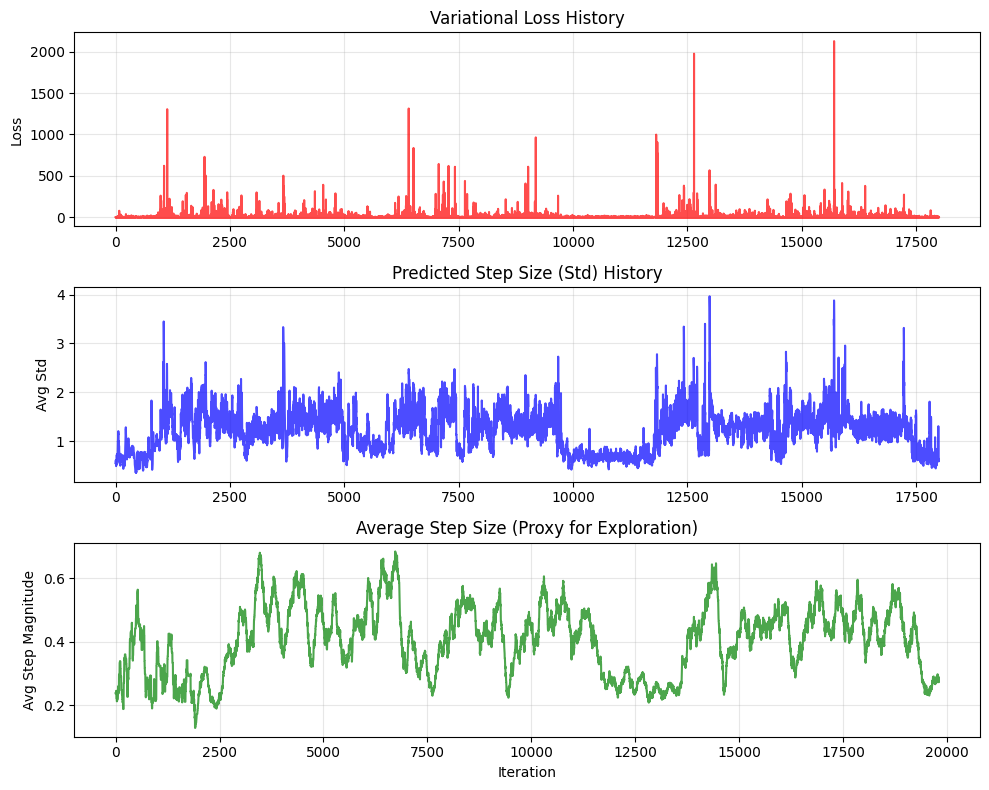

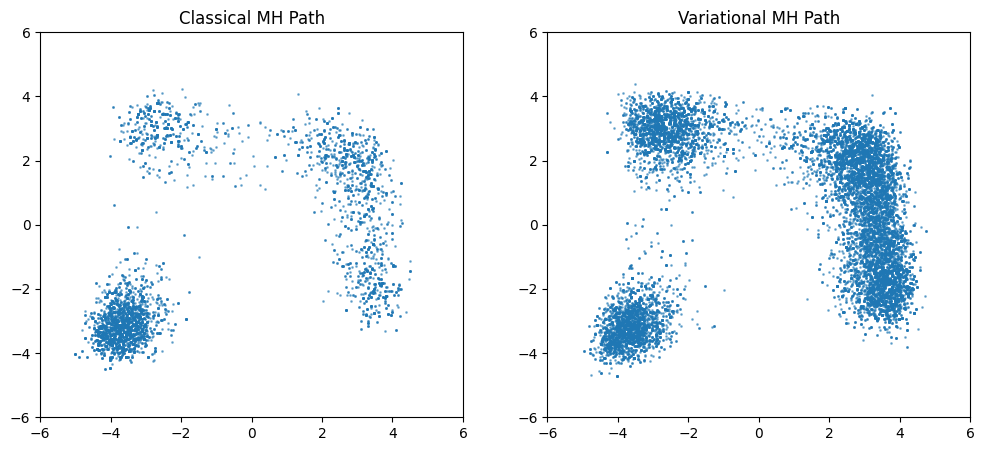

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Loss & Std History ---
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

# Plot Loss
axes[0].plot(loss_hist_var, color='red', alpha=0.7)
axes[0].set_title('Variational Loss History')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)

# Plot Predicted Standard Deviation (Average over dimensions)
axes[1].plot(std_hist_var, color='blue', alpha=0.7)
axes[1].set_title('Predicted Step Size (Std) History')
axes[1].set_ylabel('Avg Std')
axes[1].grid(alpha=0.3)

# Plot Acceptance Rate (Sliding Window)
window = 200
acc_rates = []
for i in range(window, len(samples_variational)):
    window_samples = samples_variational[i-window:i+1]
    # Calculate local acc rate by checking how many unique points vs total
    # Note: This is an approximation. For exact acc rate, we need to store flags.
    # Instead, let's just plot the trace volatility as a proxy for step size effectiveness
    diffs = np.diff(window_samples, axis=0)
    avg_step_size = np.mean(np.sqrt(np.sum(diffs**2, axis=1)))
    acc_rates.append(avg_step_size)

axes[2].plot(acc_rates, color='green', alpha=0.7)
axes[2].set_title('Average Step Size (Proxy for Exploration)')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('Avg Step Magnitude')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- 3. Trace Comparison (Classical vs Variational) ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(samples_classical[:, 0], samples_classical[:, 1], '.', markersize=2, alpha=0.5)
plt.title('Classical MH Path')
plt.xlim(-6, 6); plt.ylim(-6, 6)

plt.subplot(1, 2, 2)
plt.plot(samples_variational[:, 0], samples_variational[:, 1], '.', markersize=2, alpha=0.5)
plt.title('Variational MH Path')
plt.xlim(-6, 6); plt.ylim(-6, 6)
plt.show()

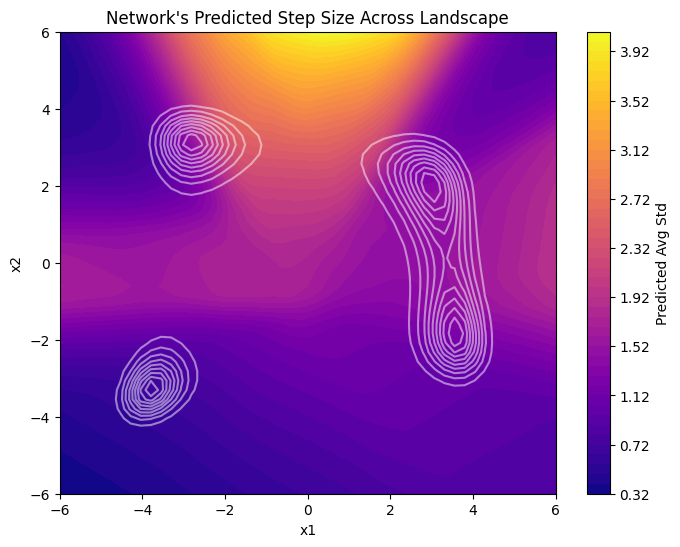

In [15]:
# --- State-Dependent Variance Map ---
# Let's see what std the network predicts across the entire 2D space
x_range = np.linspace(-6, 6, 50)
y_range = np.linspace(-6, 6, 50)
X, Y = np.meshgrid(x_range, y_range)
grid_points = np.dstack((X, Y)).reshape(-1, 2)

with torch.no_grad():
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32)
    pred_log_std = var_model(grid_tensor)
    pred_std = np.exp(pred_log_std.numpy())
    avg_pred_std = np.mean(pred_std, axis=1).reshape(50, 50)

plt.figure(figsize=(8, 6))
plt.contourf(X, Y, avg_pred_std, levels=50, cmap='plasma')
plt.colorbar(label='Predicted Avg Std')
plt.title('Network\'s Predicted Step Size Across Landscape')
plt.xlabel('x1'); plt.ylabel('x2')

# Overlay true contours
Z = np.exp(log_prob_himmelblau(np.dstack((X, Y)), T=T_TEMP))
plt.contour(X, Y, Z, levels=10, colors='white', alpha=0.5)
plt.show()

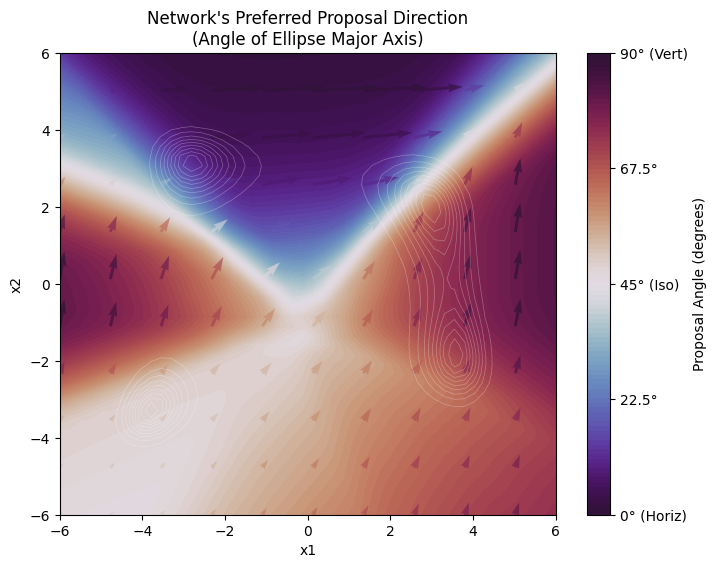

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# --- 1. Generate Grid and Predict Std Devs ---
x_range = np.linspace(-6, 6, 50)
y_range = np.linspace(-6, 6, 50)
X, Y = np.meshgrid(x_range, y_range)
grid_points = np.dstack((X, Y)).reshape(-1, 2)

with torch.no_grad():
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32)
    # Model outputs log_std for each dimension: shape (N, 2)
    pred_log_std = var_model(grid_tensor)
    pred_std = np.exp(pred_log_std.numpy()) # Shape (N, 2) -> [std_x, std_y]

# Extract std for x and y dimensions
std_x = pred_std[:, 0].reshape(50, 50)
std_y = pred_std[:, 1].reshape(50, 50)

# --- 2. Calculate Direction Angle ---
# Angle theta = arctan(std_y / std_x)
# Result is in radians [0, pi/2] since stds are positive
angles_rad = np.arctan2(std_y, std_x)
angles_deg = np.degrees(angles_rad)

# --- 3. Plotting the Direction Map ---
plt.figure(figsize=(8, 6))

# Use 'twilight' or 'hsv' colormap to represent angles cyclically
# vmin=0, vmax=90 maps Blue->Red to 0->90 degrees
cf = plt.contourf(X, Y, angles_deg, levels=np.linspace(0, 90, 100), cmap='twilight_shifted')
cbar = plt.colorbar(cf, label='Proposal Angle (degrees)')
cbar.set_ticks([0, 22.5, 45, 67.5, 90])
cbar.set_ticklabels(['0° (Horiz)', '22.5°', '45° (Iso)', '67.5°', '90° (Vert)'])

plt.title('Network\'s Preferred Proposal Direction\n(Angle of Ellipse Major Axis)')
plt.xlabel('x1'); plt.ylabel('x2')

# Overlay true contours to see if direction aligns with landscape geometry
Z = np.exp(log_prob_himmelblau(np.dstack((X, Y)), T=T_TEMP))
plt.contour(X, Y, Z, levels=10, colors='white', alpha=0.3, linewidths=0.5)

# Optional: Add quiver plot to show vectors explicitly (subsampled for clarity)
skip = 5
plt.quiver(X[::skip, ::skip], Y[::skip, ::skip], 
           std_x[::skip, ::skip], std_y[::skip, ::skip], 
           angles_deg[::skip, ::skip], 
           cmap='twilight_shifted', scale=50, alpha=0.7)

plt.show()

## 4. Quantitative and Qualitative Comparison

In [17]:
def sample_with_trained_model(model, log_prob_fn, n_samples, initial_state, 
                              min_std=0.1, T=20.0):
    """
    Run MCMC using a FIXED trained model (Inference Mode).
    No training updates occur.
    """
    dim = len(initial_state)
    samples = np.zeros((n_samples, dim))
    current_state = np.array(initial_state, dtype=float)
    
    model.eval() # Set to evaluation mode
    
    accepted_count = 0
    
    print(f"Sampling {n_samples} points with trained model...")
    
    with torch.no_grad(): # Disable gradient calculation for speed
        for i in range(n_samples):
            current_tensor = torch.tensor(current_state, dtype=torch.float32).unsqueeze(0)
            
            # 1. Get Step Size from Model
            log_std_fwd = model(current_tensor)
            std_fwd = torch.clamp(torch.exp(log_std_fwd), min=min_std)
            
            # 2. Propose
            dist_fwd = torch.distributions.Normal(current_tensor, std_fwd)
            proposal_tensor = dist_fwd.sample() # Regular sample, no rsample needed here
            proposal_np = proposal_tensor.numpy()[0]
            
            # 3. Compute Acceptance Ratio (Strict MH)
            current_log_p = log_prob_fn(current_state, T=T)
            proposal_log_p = log_prob_fn(proposal_np, T=T)
            log_target_ratio = proposal_log_p - current_log_p
            
            # Hastings Correction
            log_q_fwd = dist_fwd.log_prob(proposal_tensor).sum(dim=1).item()
            
            # Backward Proposal
            log_std_bwd = model(proposal_tensor)
            std_bwd = torch.clamp(torch.exp(log_std_bwd), min=min_std)
            dist_bwd = torch.distributions.Normal(proposal_tensor, std_bwd)
            log_q_bwd = dist_bwd.log_prob(current_tensor).sum(dim=1).item()
            
            log_correction = log_q_bwd - log_q_fwd
            log_alpha = min(log_target_ratio + log_correction, 0.0)
            
            # 4. Accept/Reject
            if np.log(np.random.rand()) < log_alpha:
                current_state = proposal_np
                accepted_count += 1
            
            samples[i] = current_state
            
            if (i+1) % 1000 == 0:
                print(f"  Sampled {i+1}/{n_samples}, Acc Rate: {accepted_count/(i+1):.3f}")
                
    model.train() # Reset to train mode if needed later
    return samples, accepted_count / n_samples

# --- Execute Inference Sampling ---
INITIAL_STATE_INF = [0.0, 0.0]

samples_inference, acc_rate_inference = sample_with_trained_model(
    var_model, 
    log_prob_himmelblau_torch, 
    N_SAMPLES, 
    INITIAL_STATE_INF, 
    min_std=0.1, 
    T=T_TEMP
)
print(f"Inference Acceptance Rate: {acc_rate_inference:.3f}")

Sampling 6000 points with trained model...
  Sampled 1000/6000, Acc Rate: 0.346
  Sampled 2000/6000, Acc Rate: 0.346
  Sampled 3000/6000, Acc Rate: 0.345
  Sampled 4000/6000, Acc Rate: 0.346
  Sampled 5000/6000, Acc Rate: 0.337
  Sampled 6000/6000, Acc Rate: 0.343
Inference Acceptance Rate: 0.343


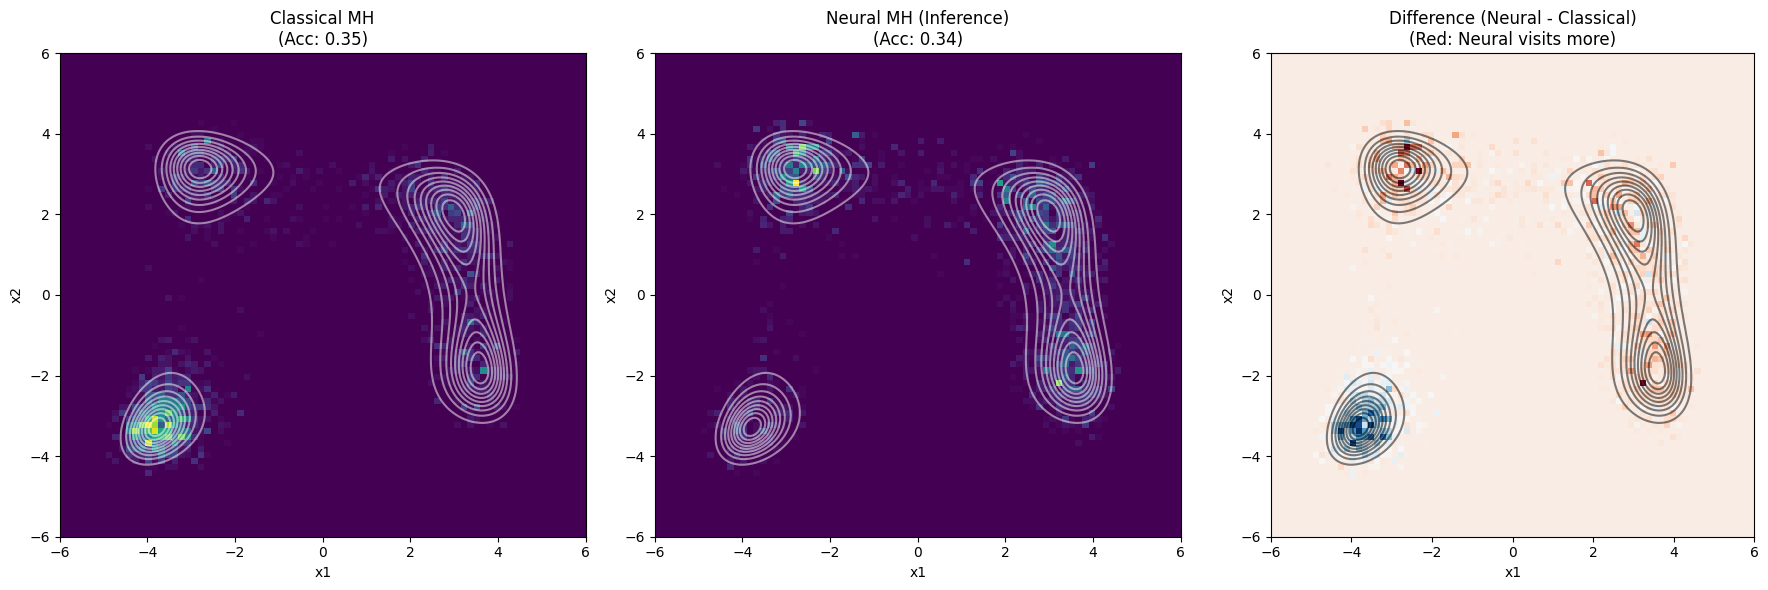

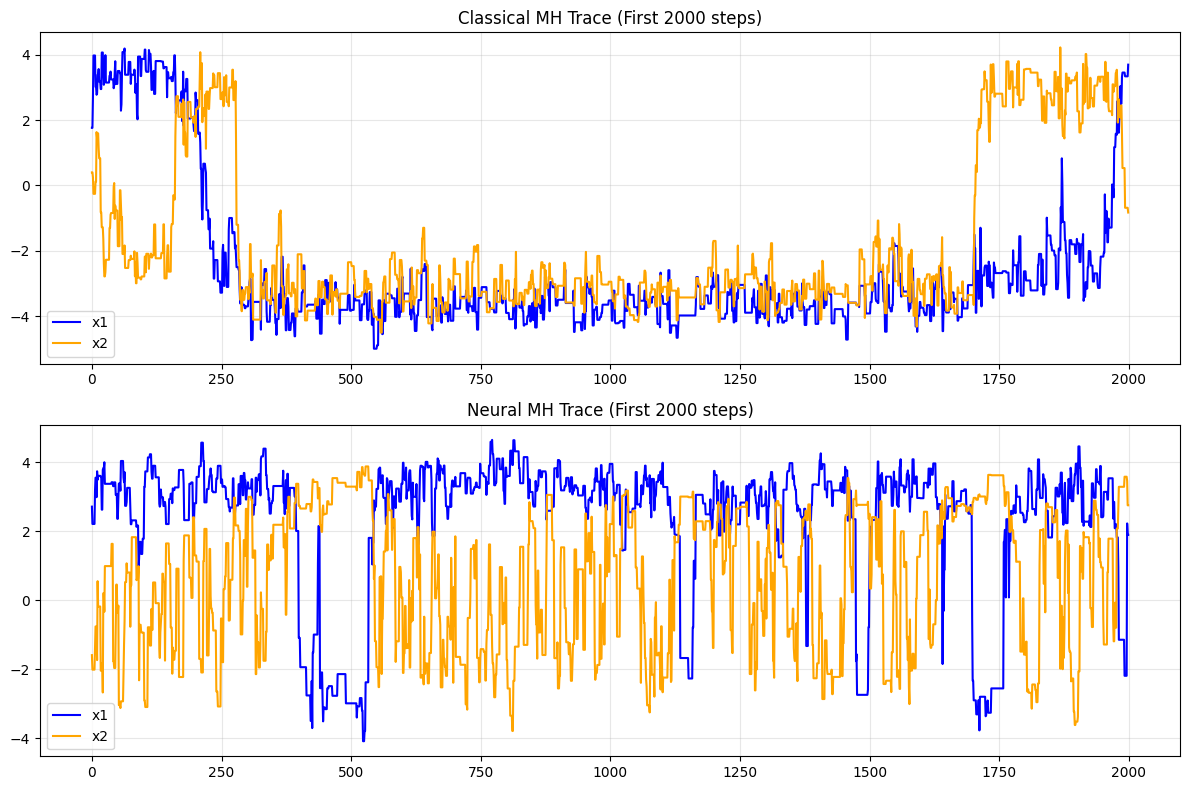

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. 2D Histogram Comparison ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Helper for contours
x_range = np.linspace(-6, 6, 200)
y_range = np.linspace(-6, 6, 200)
X, Y = np.meshgrid(x_range, y_range)
Z = np.exp(log_prob_himmelblau(np.dstack((X, Y)), T=T_TEMP))

# Classical
axes[0].hist2d(samples_classical[BURN_IN:, 0], samples_classical[BURN_IN:, 1], 
               bins=80, cmap='viridis', range=[[-6, 6], [-6, 6]])
axes[0].contour(X, Y, Z, levels=10, colors='white', alpha=0.5)
axes[0].set_title(f'Classical MH\n(Acc: {acc_rate_classical:.2f})')
axes[0].set_xlabel('x1'); axes[0].set_ylabel('x2')

# Neural (Inference)
axes[1].hist2d(samples_inference[BURN_IN:, 0], samples_inference[BURN_IN:, 1], 
               bins=80, cmap='viridis', range=[[-6, 6], [-6, 6]])
axes[1].contour(X, Y, Z, levels=10, colors='white', alpha=0.5)
axes[1].set_title(f'Neural MH (Inference)\n(Acc: {acc_rate_inference:.2f})')
axes[1].set_xlabel('x1'); axes[1].set_ylabel('x2')

# Difference Plot (Neural - Classical)
# Normalize histograms to probability densities for fair comparison
H_class, _, _ = np.histogram2d(samples_classical[BURN_IN:, 0], samples_classical[BURN_IN:, 1], 
                               bins=80, range=[[-6, 6], [-6, 6]])
H_neural, _, _ = np.histogram2d(samples_inference[BURN_IN:, 0], samples_inference[BURN_IN:, 1], 
                                bins=80, range=[[-6, 6], [-6, 6]])
H_diff = H_neural - H_class

axes[2].imshow(H_diff.T, origin='lower', extent=[-6, 6, -6, 6], cmap='RdBu_r')
axes[2].contour(X, Y, Z, levels=10, colors='black', alpha=0.5)
axes[2].set_title('Difference (Neural - Classical)\n(Red: Neural visits more)')
axes[2].set_xlabel('x1'); axes[2].set_ylabel('x2')

plt.tight_layout()
plt.show()

# --- 2. Trace Comparison (Traversing Speed) ---
plt.figure(figsize=(12, 8))

# Classical Trace
plt.subplot(2, 1, 1)
plt.plot(samples_classical[:2000, 0], label='x1', color='blue')
plt.plot(samples_classical[:2000, 1], label='x2', color='orange')
plt.title('Classical MH Trace (First 2000 steps)')
plt.legend(); plt.grid(alpha=0.3)

# Neural Trace
plt.subplot(2, 1, 2)
plt.plot(samples_inference[:2000, 0], label='x1', color='blue')
plt.plot(samples_inference[:2000, 1], label='x2', color='orange')
plt.title('Neural MH Trace (First 2000 steps)')
plt.legend(); plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
def count_mode_visits(samples, minima, radius=1.0):
    counts = np.zeros(len(minima))
    for s in samples:
        dists = np.sqrt(np.sum((s - minima)**2, axis=1))
        closest = np.argmin(dists)
        if dists[closest] < radius:
            counts[closest] += 1
    return counts

# Define Minima
minima = np.array([[3.0, 2.0], [-2.8, 3.1], [-3.8, -3.3], [3.6, -1.8]])

visits_classical = count_mode_visits(samples_classical[BURN_IN:], minima)
visits_neural = count_mode_visits(samples_inference[BURN_IN:], minima)

print("--- FINAL COMPARISON ---")
print(f"{'Metric':<20} | {'Classical':<10} | {'Neural (AI)':<10}")
print("-" * 45)
print(f"{'Acceptance Rate':<20} | {acc_rate_classical:<10.3f} | {acc_rate_inference:<10.3f}")
print(f"{'Mode 1 Visits':<20} | {visits_classical[0]:<10.0f} | {visits_neural[0]:<10.0f}")
print(f"{'Mode 2 Visits':<20} | {visits_classical[1]:<10.0f} | {visits_neural[1]:<10.0f}")
print(f"{'Mode 3 Visits':<20} | {visits_classical[2]:<10.0f} | {visits_neural[2]:<10.0f}")
print(f"{'Mode 4 Visits':<20} | {visits_classical[3]:<10.0f} | {visits_neural[3]:<10.0f}")

--- FINAL COMPARISON ---
Metric               | Classical  | Neural (AI)
---------------------------------------------
Acceptance Rate      | 0.346      | 0.343     
Mode 1 Visits        | 580        | 892       
Mode 2 Visits        | 501        | 1169      
Mode 3 Visits        | 2386       | 301       
Mode 4 Visits        | 317        | 879       


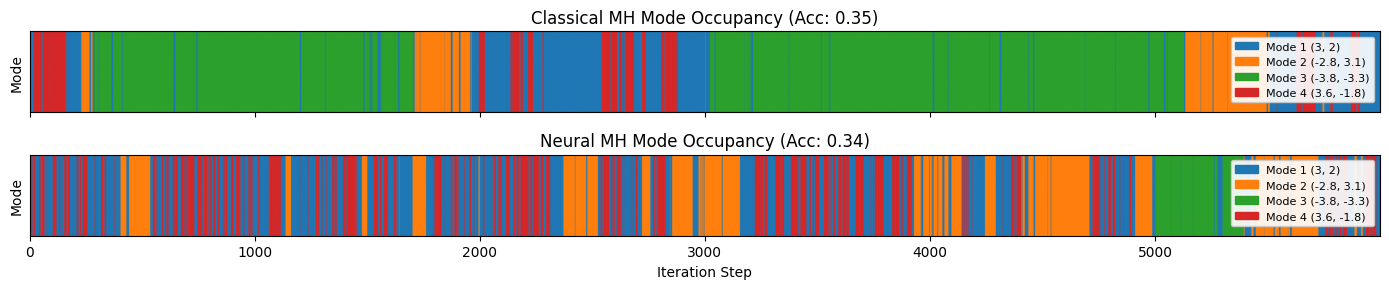

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# --- 1. Define Mode Colors and Mapping ---
# Colors for the 4 modes: Blue, Orange, Green, Red
mode_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 
cmap_modes = ListedColormap(mode_colors)

# Minima coordinates for assignment
minima = np.array([
    [3.0, 2.0],       # Mode 1
    [-2.8, 3.1],      # Mode 2
    [-3.8, -3.3],     # Mode 3
    [3.6, -1.8]       # Mode 4
])

def get_mode_indices(samples, minima, radius=1.5):
    """
    Assign each sample to a mode index (0-3) or -1 if in transition/valley.
    """
    n_samples = samples.shape[0]
    mode_indices = np.full(n_samples, -1) # -1 means "unassigned/valley"
    
    for i in range(n_samples):
        s = samples[i]
        dists = np.sqrt(np.sum((s - minima)**2, axis=1))
        min_dist = np.min(dists)
        
        if min_dist < radius:
            mode_indices[i] = np.argmin(dists)
            
    return mode_indices

# --- 2. Process Data ---
# Use all samples (including burn-in) to show the full journey
indices_classical = get_mode_indices(samples_classical, minima, radius=1.5)
indices_neural = get_mode_indices(samples_inference, minima, radius=1.5)

# --- 3. Plotting ---
fig, axes = plt.subplots(2, 1, figsize=(14, 3), sharex=True)

# Helper to plot the bar
def plot_mode_bar(ax, indices, title):
    # Create a 1xN array for imshow
    data = indices.reshape(1, -1)
    ax.imshow(data, aspect='auto', cmap=cmap_modes, vmin=-0.5, vmax=3.5)
    ax.set_title(title, fontsize=12)
    ax.set_yticks([])
    ax.set_ylabel('Mode')
    
    # Add legend manually
    handles = [plt.Rectangle((0,0),1,1, color=c) for c in mode_colors]
    labels = ['Mode 1 (3, 2)', 'Mode 2 (-2.8, 3.1)', 'Mode 3 (-3.8, -3.3)', 'Mode 4 (3.6, -1.8)']
    ax.legend(handles, labels, loc='upper right', fontsize=8, framealpha=0.9)

# Plot Classical
plot_mode_bar(axes[0], indices_classical, f'Classical MH Mode Occupancy (Acc: {acc_rate_classical:.2f})')

# Plot Neural
plot_mode_bar(axes[1], indices_neural, f'Neural MH Mode Occupancy (Acc: {acc_rate_inference:.2f})')

axes[1].set_xlabel('Iteration Step')
plt.tight_layout()
plt.show()